In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math

## Part 1: homoscedastic Gaussian distribution

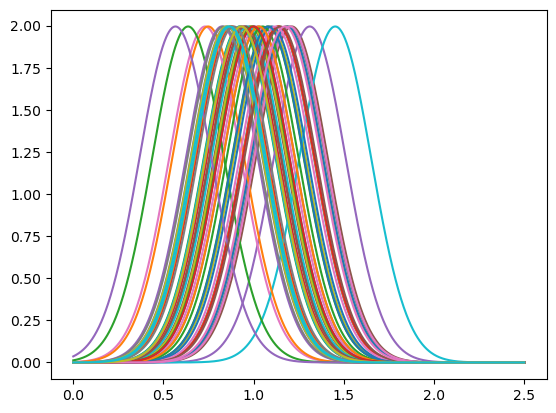

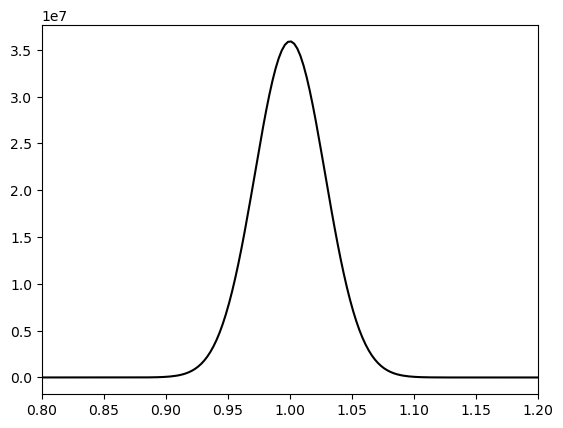

In [114]:
#fake mesuraments of N quasars distributed as a gaussian with known mu and sigma
mu = 1
sigma = 0.2
N = 1000
Nrand = 50
xi=np.random.normal(mu, sigma, Nrand)
x_plot = np.linspace(0, 2.5, N)
L = 1 #define the likelihood for the products of all the likelihoods for each xi

#define a gaussian distribution for each xi and then plots its likelihood
for i in xi:
    dist = norm(i, sigma)
    plt.plot(x_plot, dist.pdf(x_plot)) #singles likelihoods
    L *= dist.pdf(x_plot) #final likelihood as a product of all the singles likelihood
plt.show()

plt.plot(x_plot,L, color='black')
plt.xlim(0.8,1.2)
plt.show()

In [115]:
#comparison of the likelihood solution with de MLE estimator derived
Lmax = x_plot[np.argmax(L)]
print('Likelihood max:', Lmax)
print('MLE:', np.mean(xi))

Likelihood max: 1.001001001001001
MLE: 1.0001185292187973


## Part 2 (errors)

Numerical error on mu:  0.028284271247455296
Analitical error on mu:  0.0282842712474619


(0.8, 1.2)

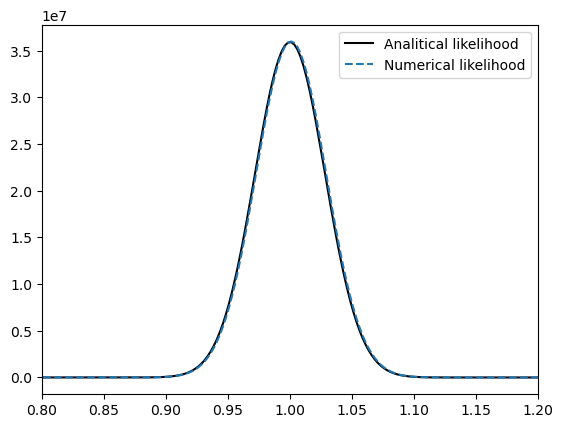

In [125]:
#rough 2nd order derivative with np.diff used recursively (or with n=2)
L2diff = np.diff(np.log(L[L>0]), n=2)[np.argmax(L)] / (np.diff(x_plot[L>0])**2)[np.argmax(L)]

print('Numerical error on mu: ', 1/((-L2diff)**0.5))
print('Analitical error on mu: ', sigma/(Nrand**0.5))

dist = norm(loc=Lmax, scale=(1/(-L2diff)**(0.5)))
plt.plot(x_plot, L, label='Analitical likelihood', color='black')
plt.plot(np.linspace(0, 2.5, N), dist.pdf(np.linspace(0, 2.5, N))*2.55*10**6, '--', label='Numerical likelihood')
plt.legend()
plt.xlim(0.8,1.2)

## Part 3: heteroscedastic Gaussian distribution

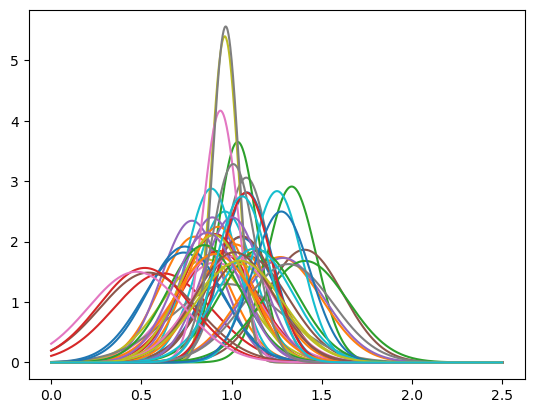

(0.8, 1.2)

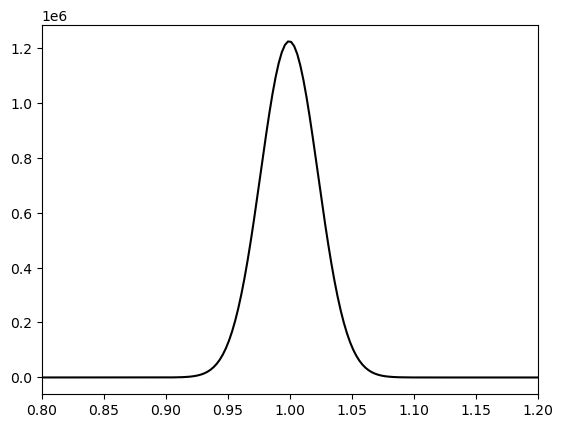

In [126]:
mu = 1
Nrand = 50
N = 1000
sigma = np.random.normal(0.2, 0.05, Nrand)
xi=np.random.normal(mu, sigma, Nrand)
x_plot = np.linspace(0, 2.5, N)
L = 1 #define the likelihood for the products of all the likelihoods for each xi

#define a gaussian distribution for each xi and then plots its likelihood
for i,j in zip(xi,sigma):
    dist = norm(i, j)
    plt.plot(x_plot, dist.pdf(x_plot)) #singles likelihoods
    L *= dist.pdf(x_plot) #final likelihood as a product of all the singles likelihood

plt.show()
plt.plot(x_plot,L, color='black')
plt.xlim(0.8,1.2)

In [127]:
#comparison of the likelihood solution with de MLE estimator derived 
Lmax = x_plot[np.argmax(L)]
print('Likelihood max:',Lmax)
print('MLE:',np.sum(xi/sigma**2)/np.sum(sigma**-2))

Likelihood max: 0.9984984984984985
MLE: 0.9995074188847538


Numerical error on mu:  0.023105411445611693
Analitical error on mu:  0.02310541144560942


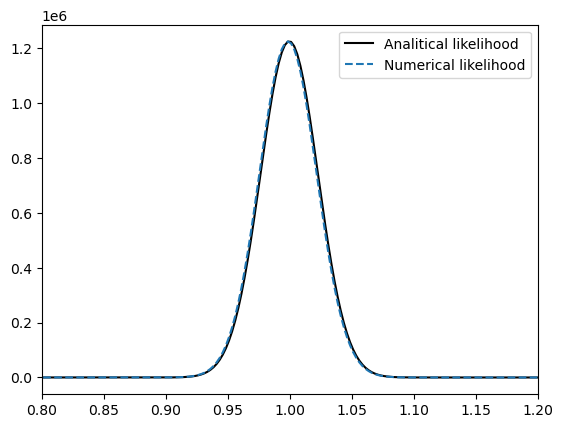

In [132]:
#rough 2nd order derivative with np.diff used recursively (or with n=2 ?)
L2diff = np.diff(np.log(L[L>0]), n=2)[np.argmax(L)] / (np.diff(x_plot[L>0])**2)[np.argmax(L)]

print('Numerical error on mu: ', 1/(-L2diff)**(0.5))
print('Analitical error on mu: ', (np.sum(sigma**-2))**-0.5)

dist = norm(loc=Lmax,scale=(1/(-L2diff)**(0.5)))
plt.plot(x_plot, L, color='black', label='Analitical likelihood')
plt.plot(np.linspace(0, 2.5, N), dist.pdf(np.linspace(0, 2.5, N))*7.08*10**4, '--', label='Numerical likelihood')
plt.legend()
plt.xlim(0.8,1.2)
plt.show()